# Phase 12 — Final Visualizations

**Archived Kaggle research notebook.** Paths refer to the original Kaggle environment. Review path variables before execution. Some cleanup cells intentionally remove large temporary artifacts under `/kaggle/working`; run those cells only when the targets have been checked. Large datasets, model weights, adapters, and checkpoints are excluded from this GitHub repository.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PHASE11_DIR = "/kaggle/working/phase11-results"
PLOT_DIR = "/kaggle/working/phase12-results/plots"

os.makedirs(PLOT_DIR, exist_ok=True)

print("Plot directory:")
print(PLOT_DIR)

Plot directory:
/kaggle/working/phase12-results/plots


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "phase11" in f.lower():
            print(os.path.join(root, f))

/kaggle/input/datasets/lucky10406/phase-11-result/PHASE11_SUMMARY.txt


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if (
            "master_comparison" in f.lower()
            or "pareto_analysis" in f.lower()
            or "rare_class" in f.lower()
            or "phase11" in root.lower()
        ):
            print(os.path.join(root, f))

/kaggle/input/datasets/lucky10406/phase-11-result/rare_class_comparison.csv
/kaggle/input/datasets/lucky10406/phase-11-result/pareto_analysis.csv
/kaggle/input/datasets/lucky10406/phase-11-result/master_comparison.csv


In [4]:
PHASE11_DIR = "/kaggle/input/datasets/lucky10406/phase-11-result"

METRICS_PATH = os.path.join(
    PHASE11_DIR,
    "master_comparison.csv"
)

results_df = pd.read_csv(METRICS_PATH)

print("Shape:", results_df.shape)
print("\nColumns:")
print(results_df.columns.tolist())

print("\nModels:")
print(results_df["model"].tolist())

display(results_df)

Shape: (8, 14)

Columns:
['model', 'family', 'usable', 'accuracy', 'macro_f1', 'weighted_f1', 'median_latency_s', 'throughput_sps', 'peak_gpu_memory_gb', 'energy_100_kwh', 'co2_100_g', 'checkpoint_size_gb', 'parameters', 'unmatched_rate']

Models:
['FP16_Qwen', 'INT8_Qwen', 'INT4_NF4_Qwen', 'Pruned_30', 'Pruned_50', 'Pruned_70', 'Distilled_DistilBERT', 'HardLabel_DistilBERT']


,model,family,usable,accuracy,macro_f1,weighted_f1,median_latency_s,throughput_sps,peak_gpu_memory_gb,energy_100_kwh,co2_100_g,checkpoint_size_gb,parameters,unmatched_rate
0,FP16_Qwen,baseline,True,0.7410,0.732506,0.731099,0.782000,1.271000,5.7690,0.002609,1.180826,5.763000,3085938688,0.000
1,INT8_Qwen,quantization,True,0.7310,0.723200,0.723200,2.849000,0.351000,3.2450,0.007451,3.372481,NaN,3085938688,0.000
2,INT4_NF4_Qwen,quantization,True,0.7565,0.749700,0.749000,1.074000,0.929000,1.9750,0.003439,1.556429,NaN,3085938688,0.000
3,Pruned_30,pruning,True,0.6395,0.633302,0.631810,1.001760,0.994916,2.8954,0.002975,1.346423,5.763000,3085938688,0.003
4,Pruned_50,pruning,False,0.0005,0.001399,0.000986,0.753602,1.325423,5.7688,0.002516,1.138794,NaN,3085938688,0.996
5,Pruned_70,pruning,False,0.0000,0.000000,0.000000,0.782443,1.276216,5.8273,0.002447,1.107499,NaN,3085938688,1.000
6,Distilled_DistilBERT,distillation,True,0.7735,0.762968,0.771577,0.004378,227.363706,0.2681,0.000014,0.006397,0.250126,66961162,0.000
7,HardLabel_DistilBERT,ablation,True,0.7640,0.746696,0.755115,NaN,223.424311,NaN,NaN,NaN,NaN,66961162,0.000


In [5]:
PARETO_PATH = os.path.join(
    PHASE11_DIR,
    "pareto_analysis.csv"
)

RARE_CLASS_PATH = os.path.join(
    PHASE11_DIR,
    "rare_class_comparison.csv"
)

pareto_df = pd.read_csv(PARETO_PATH)
rare_class_df = pd.read_csv(RARE_CLASS_PATH)

print("\nPareto results:")
display(pareto_df)

print("\nRare-class comparison:")
display(rare_class_df)


Pareto results:


,model,family,usable,accuracy,macro_f1,weighted_f1,median_latency_s,throughput_sps,peak_gpu_memory_gb,energy_100_kwh,co2_100_g,checkpoint_size_gb,parameters,unmatched_rate,dominated
0,FP16_Qwen,baseline,True,0.7410,0.732506,0.731099,0.782000,1.271000,5.7690,0.002609,1.180826,5.763000,3085938688,0.000,True
1,INT8_Qwen,quantization,True,0.7310,0.723200,0.723200,2.849000,0.351000,3.2450,0.007451,3.372481,NaN,3085938688,0.000,True
2,INT4_NF4_Qwen,quantization,True,0.7565,0.749700,0.749000,1.074000,0.929000,1.9750,0.003439,1.556429,NaN,3085938688,0.000,True
3,Pruned_30,pruning,True,0.6395,0.633302,0.631810,1.001760,0.994916,2.8954,0.002975,1.346423,5.763000,3085938688,0.003,True
4,Distilled_DistilBERT,distillation,True,0.7735,0.762968,0.771577,0.004378,227.363706,0.2681,0.000014,0.006397,0.250126,66961162,0.000,False



Rare-class comparison:


,model,missing_found_f1,urgent_needs_f1
0,FP16_Qwen,0.88,0.51
1,INT8_Qwen,0.88,0.49
2,INT4_NF4_Qwen,0.88,0.52
3,Pruned_30,0.94,0.50
4,Distilled_DistilBERT,0.84,0.55


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOT_DIR = "/kaggle/working/phase12-results/plots"

os.makedirs(PLOT_DIR, exist_ok=True)

# Seconds -> milliseconds
results_df["latency_ms"] = (
    results_df["median_latency_s"] * 1000
)

# All Phase 8/9/10 energy runs used 100 examples
ENERGY_SAMPLE_COUNT = 100

# kWh for 100 predictions -> Wh for 1000 predictions
results_df["energy_wh_per_1000"] = (
    results_df["energy_100_kwh"]
    * 1000
    * 1000
    / ENERGY_SAMPLE_COUNT
)

# GB -> MB
results_df["peak_gpu_memory_mb"] = (
    results_df["peak_gpu_memory_gb"] * 1024
)

results_df["checkpoint_size_mb"] = (
    results_df["checkpoint_size_gb"] * 1024
)

DISPLAY_NAMES = {
    "FP16_Qwen": "Qwen FP16",
    "INT8_Qwen": "Qwen INT8",
    "INT4_NF4_Qwen": "Qwen INT4 NF4",
    "Pruned_30": "Qwen Pruned 30%",
    "Pruned_50": "Qwen Pruned 50%",
    "Pruned_70": "Qwen Pruned 70%",
    "Distilled_DistilBERT": "Distilled DistilBERT",
    "HardLabel_DistilBERT": "Hard-label DistilBERT"
}

results_df["display_name"] = (
    results_df["model"]
    .map(DISPLAY_NAMES)
    .fillna(results_df["model"])
)

print(
    results_df[
        [
            "display_name",
            "accuracy",
            "macro_f1",
            "latency_ms",
            "peak_gpu_memory_mb",
            "energy_wh_per_1000",
            "checkpoint_size_mb"
        ]
    ].to_string(index=False)
)

         display_name  accuracy  macro_f1  latency_ms  peak_gpu_memory_mb  energy_wh_per_1000  checkpoint_size_mb
            Qwen FP16    0.7410  0.732506  782.000000           5907.4560           26.088650         5901.312000
            Qwen INT8    0.7310  0.723200 2849.000000           3322.8800           74.510089                 NaN
        Qwen INT4 NF4    0.7565  0.749700 1074.000000           2022.4000           34.387051                 NaN
      Qwen Pruned 30%    0.6395  0.633302 1001.759562           2964.8896           29.747269         5901.312000
      Qwen Pruned 50%    0.0005  0.001399  753.601656           5907.2512           25.160002                 NaN
      Qwen Pruned 70%    0.0000  0.000000  782.443434           5967.1552           24.468577                 NaN
 Distilled DistilBERT    0.7735  0.762968    4.378194            274.5344            0.141328          256.129024
Hard-label DistilBERT    0.7640  0.746696         NaN                 NaN               

In [7]:
latency_df = results_df[
    (results_df["usable"] == True)
    &
    (results_df["family"] != "ablation")
].dropna(
    subset=[
        "latency_ms",
        "accuracy",
        "macro_f1"
    ]
).copy()


def pareto_2d(df, quality_col, cost_col):
    flags = []

    for idx, row in df.iterrows():

        dominated = False

        for other_idx, other in df.iterrows():

            if idx == other_idx:
                continue

            better_or_equal_quality = (
                other[quality_col] >= row[quality_col]
            )

            better_or_equal_cost = (
                other[cost_col] <= row[cost_col]
            )

            strictly_better = (
                other[quality_col] > row[quality_col]
                or
                other[cost_col] < row[cost_col]
            )

            if (
                better_or_equal_quality
                and better_or_equal_cost
                and strictly_better
            ):
                dominated = True
                break

        flags.append(not dominated)

    return flags


latency_df["pareto_macro_f1_latency"] = pareto_2d(
    latency_df,
    quality_col="macro_f1",
    cost_col="latency_ms"
)

print(
    latency_df[
        [
            "display_name",
            "macro_f1",
            "latency_ms",
            "pareto_macro_f1_latency"
        ]
    ].to_string(index=False)
)

        display_name  macro_f1  latency_ms  pareto_macro_f1_latency
           Qwen FP16  0.732506  782.000000                    False
           Qwen INT8  0.723200 2849.000000                    False
       Qwen INT4 NF4  0.749700 1074.000000                    False
     Qwen Pruned 30%  0.633302 1001.759562                    False
Distilled DistilBERT  0.762968    4.378194                     True


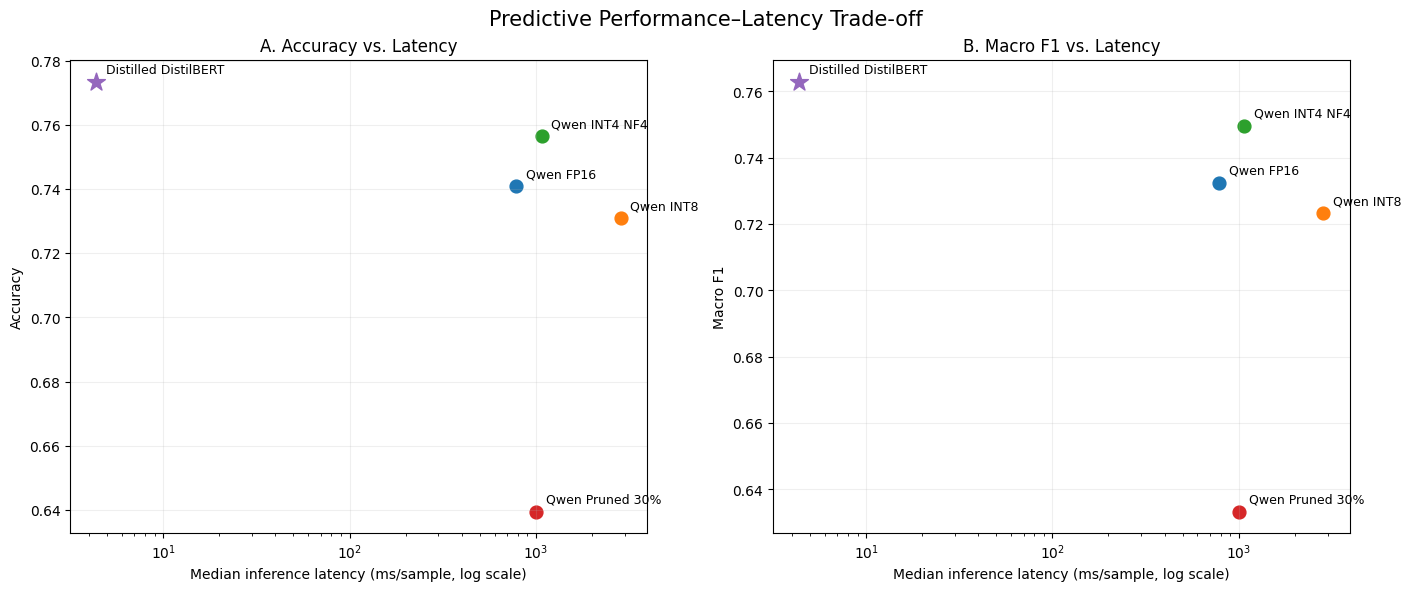

In [8]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.8),
    constrained_layout=True
)

# ---------- Accuracy ----------
ax = axes[0]

for _, row in latency_df.iterrows():

    is_pareto = row["pareto_macro_f1_latency"]

    ax.scatter(
        row["latency_ms"],
        row["accuracy"],
        s=180 if is_pareto else 85,
        marker="*" if is_pareto else "o"
    )

    ax.annotate(
        row["display_name"],
        (row["latency_ms"], row["accuracy"]),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")

ax.set_xlabel(
    "Median inference latency (ms/sample, log scale)"
)

ax.set_ylabel("Accuracy")

ax.set_title("A. Accuracy vs. Latency")

ax.grid(
    True,
    alpha=0.2
)


# ---------- Macro F1 ----------
ax = axes[1]

for _, row in latency_df.iterrows():

    is_pareto = row["pareto_macro_f1_latency"]

    ax.scatter(
        row["latency_ms"],
        row["macro_f1"],
        s=180 if is_pareto else 85,
        marker="*" if is_pareto else "o"
    )

    ax.annotate(
        row["display_name"],
        (row["latency_ms"], row["macro_f1"]),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")

ax.set_xlabel(
    "Median inference latency (ms/sample, log scale)"
)

ax.set_ylabel("Macro F1")

ax.set_title("B. Macro F1 vs. Latency")

ax.grid(
    True,
    alpha=0.2
)

fig.suptitle(
    "Predictive Performance–Latency Trade-off",
    fontsize=15
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "01_performance_vs_latency.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "01_performance_vs_latency.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [9]:
energy_df = results_df[
    (results_df["usable"] == True)
    &
    (results_df["family"] != "ablation")
    &
    (results_df["energy_wh_per_1000"].notna())
].copy()

energy_df = energy_df.sort_values(
    "energy_wh_per_1000"
)

print(
    energy_df[
        [
            "display_name",
            "energy_wh_per_1000"
        ]
    ].to_string(index=False)
)

        display_name  energy_wh_per_1000
Distilled DistilBERT            0.141328
           Qwen FP16           26.088650
     Qwen Pruned 30%           29.747269
       Qwen INT4 NF4           34.387051
           Qwen INT8           74.510089


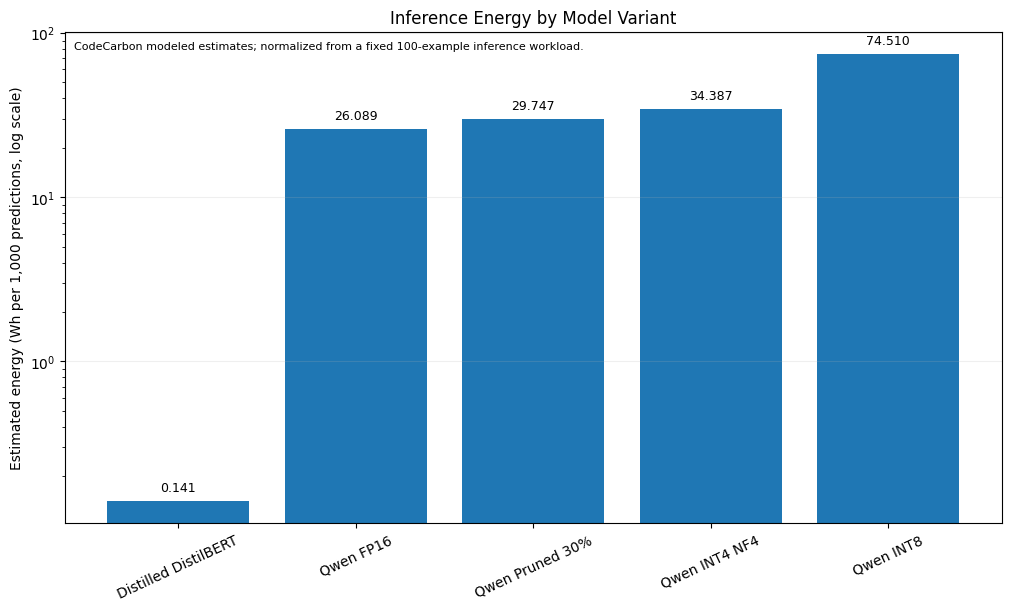

In [10]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True
)

bars = ax.bar(
    energy_df["display_name"],
    energy_df["energy_wh_per_1000"]
)

# Log scale because DistilBERT is >100x lower
ax.set_yscale("log")

ax.set_ylabel(
    "Estimated energy (Wh per 1,000 predictions, log scale)"
)

ax.set_title(
    "Inference Energy by Model Variant"
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.tick_params(
    axis="x",
    rotation=25
)

for bar, value in zip(
    bars,
    energy_df["energy_wh_per_1000"]
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value * 1.10,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.text(
    0.01,
    0.98,
    "CodeCarbon modeled estimates; normalized from a fixed 100-example inference workload.",
    transform=ax.transAxes,
    va="top",
    fontsize=8
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "02_energy_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "02_energy_comparison.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [11]:
size_df = results_df[
    results_df["model"].isin(
        [
            "FP16_Qwen",
            "Pruned_30",
            "Distilled_DistilBERT"
        ]
    )
].dropna(
    subset=["checkpoint_size_mb"]
).copy()


memory_df = results_df[
    (results_df["usable"] == True)
    &
    (results_df["family"] != "ablation")
].dropna(
    subset=["peak_gpu_memory_mb"]
).copy()

In [12]:
fp16_size = results_df.loc[
    results_df["model"] == "FP16_Qwen",
    "checkpoint_size_mb"
].iloc[0]

fp16_memory = results_df.loc[
    results_df["model"] == "FP16_Qwen",
    "peak_gpu_memory_mb"
].iloc[0]

size_df["reduction_pct"] = (
    1
    -
    size_df["checkpoint_size_mb"]
    / fp16_size
) * 100

memory_df["reduction_pct"] = (
    1
    -
    memory_df["peak_gpu_memory_mb"]
    / fp16_memory
) * 100

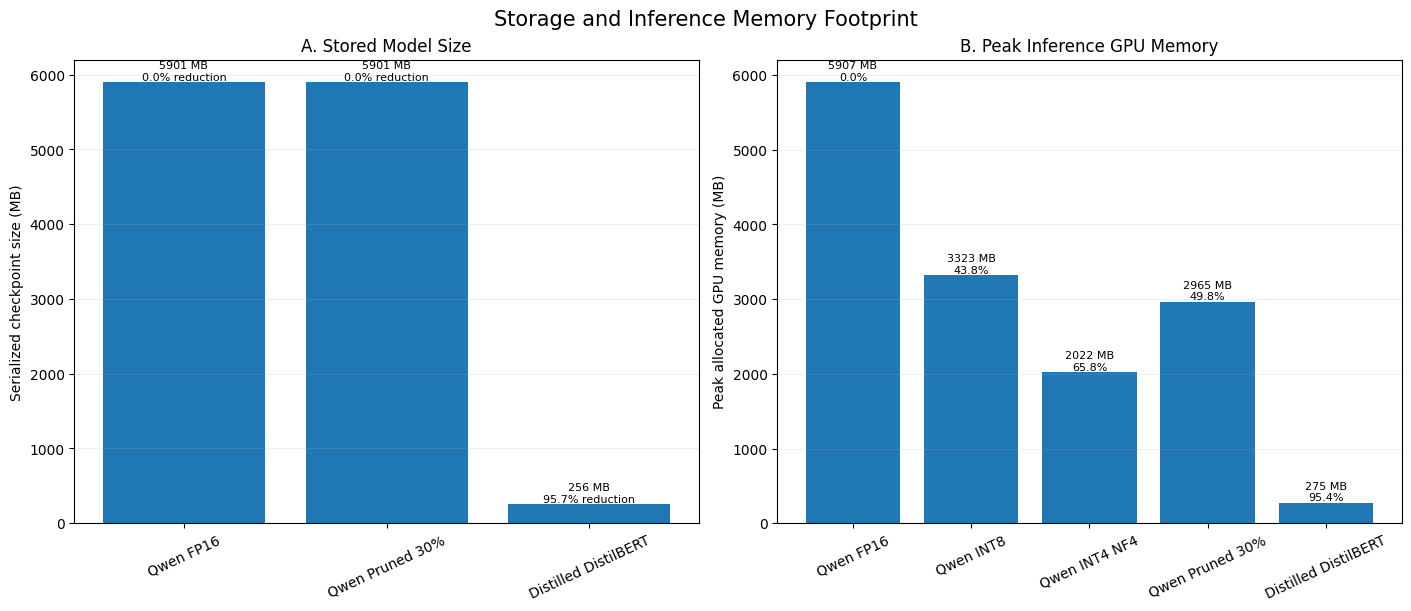

In [13]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True
)

# ---------------- Stored size ----------------

ax = axes[0]

bars = ax.bar(
    size_df["display_name"],
    size_df["checkpoint_size_mb"]
)

ax.set_ylabel(
    "Serialized checkpoint size (MB)"
)

ax.set_title(
    "A. Stored Model Size"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.grid(
    axis="y",
    alpha=0.2
)

for bar, (_, row) in zip(
    bars,
    size_df.iterrows()
):

    label = (
        f'{row["checkpoint_size_mb"]:.0f} MB\n'
        f'{row["reduction_pct"]:.1f}% reduction'
    )

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        label,
        ha="center",
        va="bottom",
        fontsize=8
    )


# ---------------- GPU memory ----------------

ax = axes[1]

bars = ax.bar(
    memory_df["display_name"],
    memory_df["peak_gpu_memory_mb"]
)

ax.set_ylabel(
    "Peak allocated GPU memory (MB)"
)

ax.set_title(
    "B. Peak Inference GPU Memory"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.grid(
    axis="y",
    alpha=0.2
)

for bar, (_, row) in zip(
    bars,
    memory_df.iterrows()
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        (
            f'{row["peak_gpu_memory_mb"]:.0f} MB\n'
            f'{row["reduction_pct"]:.1f}%'
        ),
        ha="center",
        va="bottom",
        fontsize=8
    )

fig.suptitle(
    "Storage and Inference Memory Footprint",
    fontsize=15
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "03_size_memory_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "03_size_memory_comparison.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [14]:
fp16 = results_df[
    results_df["model"] == "FP16_Qwen"
].iloc[0]

distilled = results_df[
    results_df["model"] == "Distilled_DistilBERT"
].iloc[0]

size_reduction = (
    1
    - distilled["checkpoint_size_mb"]
    / fp16["checkpoint_size_mb"]
) * 100

memory_reduction = (
    1
    - distilled["peak_gpu_memory_mb"]
    / fp16["peak_gpu_memory_mb"]
) * 100

latency_reduction = (
    1
    - distilled["latency_ms"]
    / fp16["latency_ms"]
) * 100

energy_reduction = (
    1
    - distilled["energy_wh_per_1000"]
    / fp16["energy_wh_per_1000"]
) * 100

pareto_names = latency_df.loc[
    latency_df["pareto_macro_f1_latency"],
    "display_name"
].tolist()

dominated_names = latency_df.loc[
    ~latency_df["pareto_macro_f1_latency"],
    "display_name"
].tolist()

summary_text = f"""
# Phase 12 Visualization Summary

## Figure 1 — Predictive performance versus latency

The performance-latency figure compares usable variants with directly measured
median inference latency. Macro F1 is emphasized because the HumAID dataset is
class-imbalanced.

The distilled DistilBERT student achieves the highest macro F1 among the fully
measured usable variants ({distilled['macro_f1']:.4f}) while requiring only
{distilled['latency_ms']:.2f} ms per prediction.

Pareto-optimal variant:
- {", ".join(pareto_names)}

Dominated variants:
- {", ".join(dominated_names)}

Relative to Qwen FP16, the distilled student reduces measured median latency by
approximately {latency_reduction:.2f}%.

This comparison reflects task-specific deployment efficiency. DistilBERT uses a
dedicated classification head, whereas Qwen generates labels autoregressively,
so the result should not be interpreted as evidence that DistilBERT is generally
more capable than Qwen.

## Figure 2 — Energy comparison

Inference energy was normalized to watt-hours per 1,000 predictions from the
fixed 100-example CodeCarbon workload.

Measured estimates:

- Distilled DistilBERT: {distilled['energy_wh_per_1000']:.3f} Wh / 1,000
- Qwen FP16: {fp16['energy_wh_per_1000']:.3f} Wh / 1,000

The distilled student uses approximately {energy_reduction:.2f}% less estimated
inference energy than the FP16 reference in this environment.

Among Qwen variants, FP16 has the lowest estimated energy, followed by 30%
pruning, INT4 NF4, and INT8.

CodeCarbon values are modeled estimates rather than direct physical power-meter
measurements. Differences in model architecture and device placement mean these
results should be interpreted as observed deployment-level costs on this setup.

## Figure 3 — Model size and GPU memory

The merged FP16 Qwen checkpoint occupies approximately
{fp16['checkpoint_size_mb']:.1f} MB.

The 30%-sparse model occupies the same dense serialized size, demonstrating that
unstructured zero weights do not automatically create deployable storage
compression.

The distilled DistilBERT checkpoint occupies approximately
{distilled['checkpoint_size_mb']:.1f} MB, corresponding to a
{size_reduction:.2f}% reduction relative to FP16.

Peak allocated GPU memory decreases from approximately
{fp16['peak_gpu_memory_mb']:.1f} MB to
{distilled['peak_gpu_memory_mb']:.1f} MB, a reduction of approximately
{memory_reduction:.2f}%.

INT8 and INT4 appear only in the runtime-memory comparison because deployable
serialized quantized checkpoints were not saved.

## Main trade-off

For retaining the original Qwen architecture, INT4 NF4 is the strongest tested
quantized option: it achieves macro F1 = 0.7497 while substantially reducing GPU
memory relative to FP16. However, it is slower and consumes more estimated
energy than FP16 on the tested Tesla T4 setup.

For task-specific humanitarian classification, the distilled DistilBERT student
provides the strongest observed quality-efficiency point. It improves macro F1
while using dramatically less storage, memory, latency, and estimated energy.

## Rare-category finding

The rare-category results do not show systematic disproportionate degradation
under compression. The missing/found F1 remains approximately unchanged under
INT8 and INT4, increases under 30% pruning, and decreases under distillation.
Urgent-needs F1 improves under INT4 and distillation.

Because the missing/found category has only nine examples in the fixed 2,000-
example benchmark, strong conclusions about that category would be statistically
fragile.

## Evidence-based conclusions

1. Lower numerical precision reduces GPU memory but does not automatically
   reduce latency or energy on this hardware.

2. One-shot unstructured magnitude pruning is not an effective deployment
   strategy in this experiment: 30% sparsity harms quality without shrinking
   dense storage, while 50–70% sparsity causes functional collapse.

3. Knowledge distillation into a 66.96M-parameter task-specific DistilBERT
   produces the strongest measured quality-efficiency point on this dataset and
   hardware, while teacher-soft-target training also improves over the
   hard-label-only student.
"""

SUMMARY_PATH = os.path.join(
    PLOT_DIR,
    "plot_summary.md"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

print("Saved:", SUMMARY_PATH)
print(summary_text)

Saved: /kaggle/working/phase12-results/plots/plot_summary.md

# Phase 12 Visualization Summary

## Figure 1 — Predictive performance versus latency

The performance-latency figure compares usable variants with directly measured
median inference latency. Macro F1 is emphasized because the HumAID dataset is
class-imbalanced.

The distilled DistilBERT student achieves the highest macro F1 among the fully
measured usable variants (0.7630) while requiring only
4.38 ms per prediction.

Pareto-optimal variant:
- Distilled DistilBERT

Dominated variants:
- Qwen FP16, Qwen INT8, Qwen INT4 NF4, Qwen Pruned 30%

Relative to Qwen FP16, the distilled student reduces measured median latency by
approximately 99.44%.

This comparison reflects task-specific deployment efficiency. DistilBERT uses a
dedicated classification head, whereas Qwen generates labels autoregressively,
so the result should not be interpreted as evidence that DistilBERT is generally
more capable than Qwen.

## Figure 2 — Energy co

In [15]:
plot_table_cols = [
    "model",
    "family",
    "usable",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "latency_ms",
    "throughput_sps",
    "peak_gpu_memory_mb",
    "checkpoint_size_mb",
    "energy_wh_per_1000",
    "co2_100_g"
]

PHASE12_DIR = "/kaggle/working/phase12-results"

results_df[
    plot_table_cols
].to_csv(
    os.path.join(
        PHASE12_DIR,
        "phase12_plot_data.csv"
    ),
    index=False
)

print("Saved phase12_plot_data.csv")

Saved phase12_plot_data.csv


In [16]:
required_files = [
    "01_performance_vs_latency.png",
    "01_performance_vs_latency.pdf",
    "02_energy_comparison.png",
    "02_energy_comparison.pdf",
    "03_size_memory_comparison.png",
    "03_size_memory_comparison.pdf",
    "plot_summary.md"
]

print("=" * 70)
print("PHASE 12 OUTPUT CHECK")
print("=" * 70)

all_ok = True

for filename in required_files:

    path = os.path.join(
        PLOT_DIR,
        filename
    )

    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0

    print(
        f"{filename:40s}",
        "OK" if exists and size > 0 else "MISSING",
        f"{size / 1024:.1f} KB" if size else ""
    )

    if not exists or size == 0:
        all_ok = False

print("\nAll required outputs valid:", all_ok)

PHASE 12 OUTPUT CHECK
01_performance_vs_latency.png            OK 213.0 KB
01_performance_vs_latency.pdf            OK 20.1 KB
02_energy_comparison.png                 OK 199.8 KB
02_energy_comparison.pdf                 OK 19.5 KB
03_size_memory_comparison.png            OK 283.1 KB
03_size_memory_comparison.pdf            OK 19.4 KB
plot_summary.md                          OK 3.8 KB

All required outputs valid: True


In [17]:
import shutil

ZIP_BASE = "/kaggle/working/phase12-final-backup"

shutil.make_archive(
    ZIP_BASE,
    "zip",
    PHASE12_DIR
)

ZIP_PATH = ZIP_BASE + ".zip"

print("=" * 70)
print("PHASE 12 BACKUP COMPLETE")
print("=" * 70)

print("ZIP:", ZIP_PATH)
print(
    "Size:",
    round(
        os.path.getsize(ZIP_PATH) / 1024**2,
        2
    ),
    "MB"
)

PHASE 12 BACKUP COMPLETE
ZIP: /kaggle/working/phase12-final-backup.zip
Size: 0.57 MB
